# XClinVision: Data Exploration Notebook
**Day 1: EDA & Data Preparation**

This notebook explores the chest X-ray dataset structure, visualizes samples,
and analyzes class distributions for the XClinVision project.

## 1. Setup and Imports

In [2]:
import os
import sys
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path().absolute().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from xclinvision.processing import (
    load_dataset_metadata,
    IMAGE_EXTS,
    DEFAULT_MIN_AREA_RATIO,
)

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
%load_ext autoreload
%autoreload 2

## 2. Dataset Paths Configuration

In [3]:
DATA_DIR = Path("../data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

print(f"Data directory: {DATA_DIR}")
print(f"Raw data exists: {RAW_DIR.exists()}")
print(f"Processed data exists: {PROCESSED_DIR.exists()}")

Data directory: ../data
Raw data exists: True
Processed data exists: True


## 3. Load Dataset Metadata

In [4]:
# load_dataset_metadata is imported from xclinvision.processing
# It scans raw_dir/{split}/{class}/ for images matching IMAGE_EXTS.

df = load_dataset_metadata(RAW_DIR)
print(f"\nTotal images: {len(df)}")
if len(df) > 0:
    print(f"\nPer split/class breakdown:")
    print(df.groupby(["split", "class"]).size().unstack(fill_value=0))
df.head()

Scanning train:   0%|          | 0/3 [00:00<?, ?it/s]

  normal:   0%|          | 0/8960 [00:00<?, ?it/s]

  pneumonia:   0%|          | 0/8841 [00:00<?, ?it/s]

  tuberculosis:   0%|          | 0/10250 [00:00<?, ?it/s]

Scanning val:   0%|          | 0/3 [00:00<?, ?it/s]

...

  normal:   0%|          | 0/1231 [00:00<?, ?it/s]

  pneumonia:   0%|          | 0/650 [00:00<?, ?it/s]

  tuberculosis:   0%|          | 0/1429 [00:00<?, ?it/s]


Total images: 34356

Per split/class breakdown:
class  normal  pneumonia  tuberculosis
split                                 
test     1231        650          1429
train    8960       8841         10250
val       985        578          1432


,split,class,filepath,filename
0,train,normal,../data/raw/train/normal/normal-3873.jpg,normal-3873.jpg
1,train,normal,../data/raw/train/normal/IM-0525-0001-0001.jpeg,IM-0525-0001-0001.jpeg
2,train,normal,../data/raw/train/normal/normal-3378.jpg,normal-3378.jpg
3,train,normal,../data/raw/train/normal/normal-3535.jpg,normal-3535.jpg
4,train,normal,../data/raw/train/normal/NORMAL2-IM-1128-0001-...,NORMAL2-IM-1128-0001-0002.jpeg


## 4. Class Distribution Analysis

Class Distribution:
class
tuberculosis    13111
normal          11176
pneumonia       10069
Name: count, dtype: int64


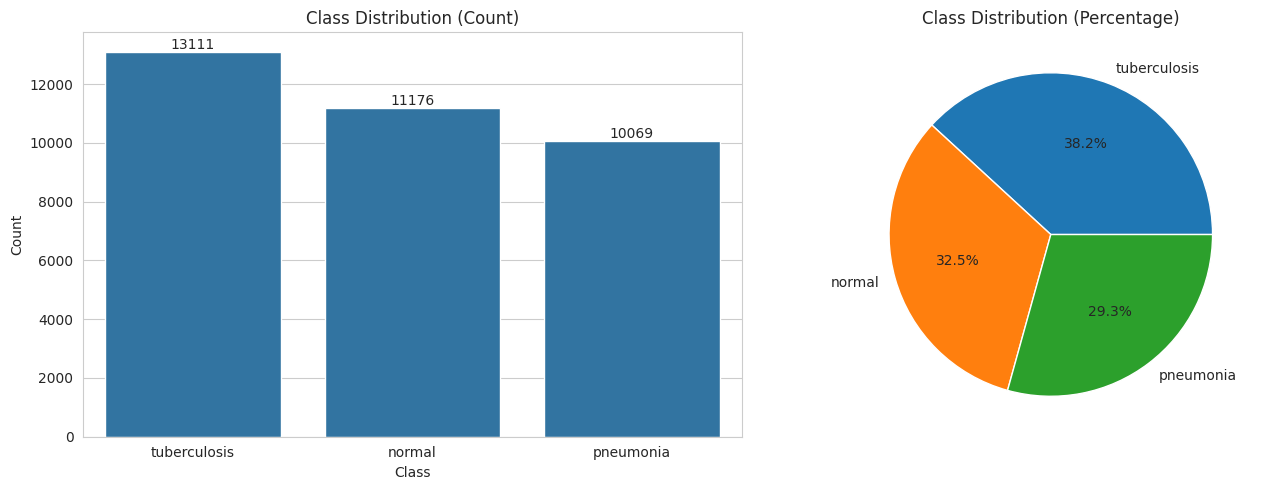

In [5]:
# Overall class distribution
class_counts = df["class"].value_counts()
print("Class Distribution:")
print(class_counts)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0])
axes[0].set_title("Class Distribution (Count)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%")
axes[1].set_title("Class Distribution (Percentage)")

plt.tight_layout()
plt.show()

## 5. Per-Split Class Distribution
Verify that the class balance is consistent across train, validation, and test splits.

Per-Split Class Counts:
class  normal  pneumonia  tuberculosis
split                                 
test     1231        650          1429
train    8960       8841         10250
val       985        578          1432



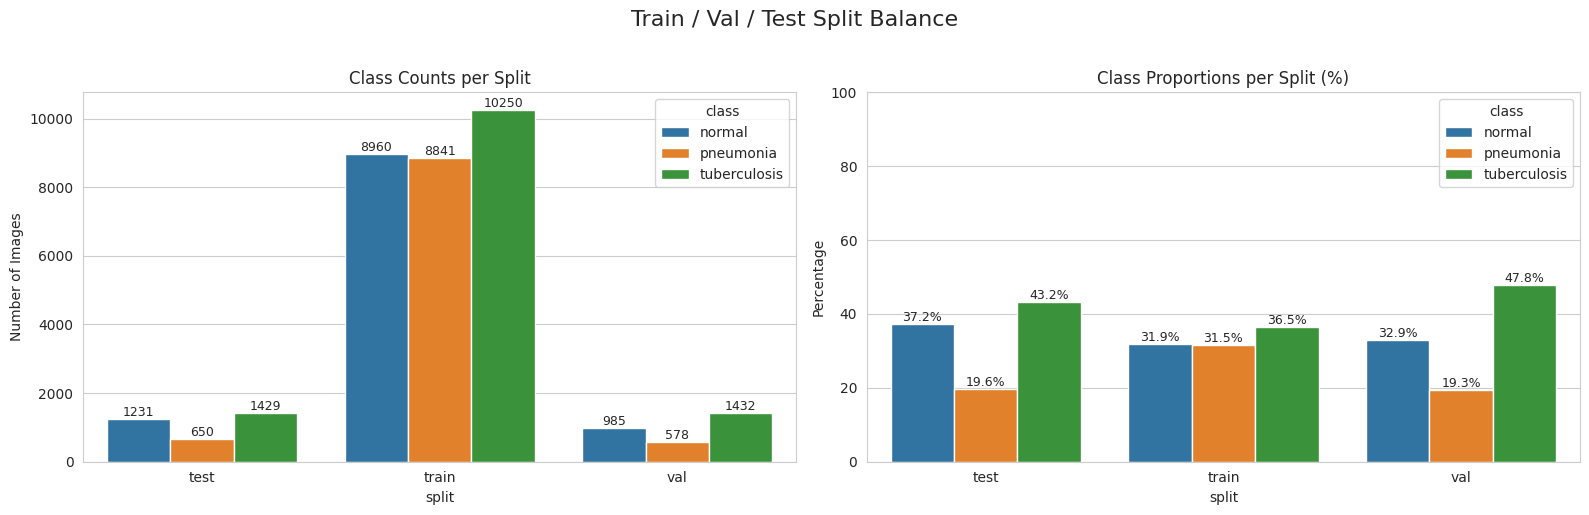

In [6]:
# Per-split class counts
split_class = df.groupby(["split", "class"]).size().unstack(fill_value=0)
print("Per-Split Class Counts:")
print(split_class)
print()

# Grouped bar chart
split_class_melted = split_class.reset_index().melt(id_vars="split", var_name="class", value_name="count")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Absolute counts
sns.barplot(data=split_class_melted, x="split", y="count", hue="class", ax=axes[0])
axes[0].set_title("Class Counts per Split")
axes[0].set_ylabel("Number of Images")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", fontsize=9)

# Proportions within each split
split_pct = split_class.div(split_class.sum(axis=1), axis=0) * 100
split_pct_melted = split_pct.reset_index().melt(id_vars="split", var_name="class", value_name="percentage")

sns.barplot(data=split_pct_melted, x="split", y="percentage", hue="class", ax=axes[1])
axes[1].set_title("Class Proportions per Split (%)")
axes[1].set_ylabel("Percentage")
axes[1].set_ylim(0, 100)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f%%", fontsize=9)

plt.suptitle("Train / Val / Test Split Balance", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 6. Sample Image Visualization

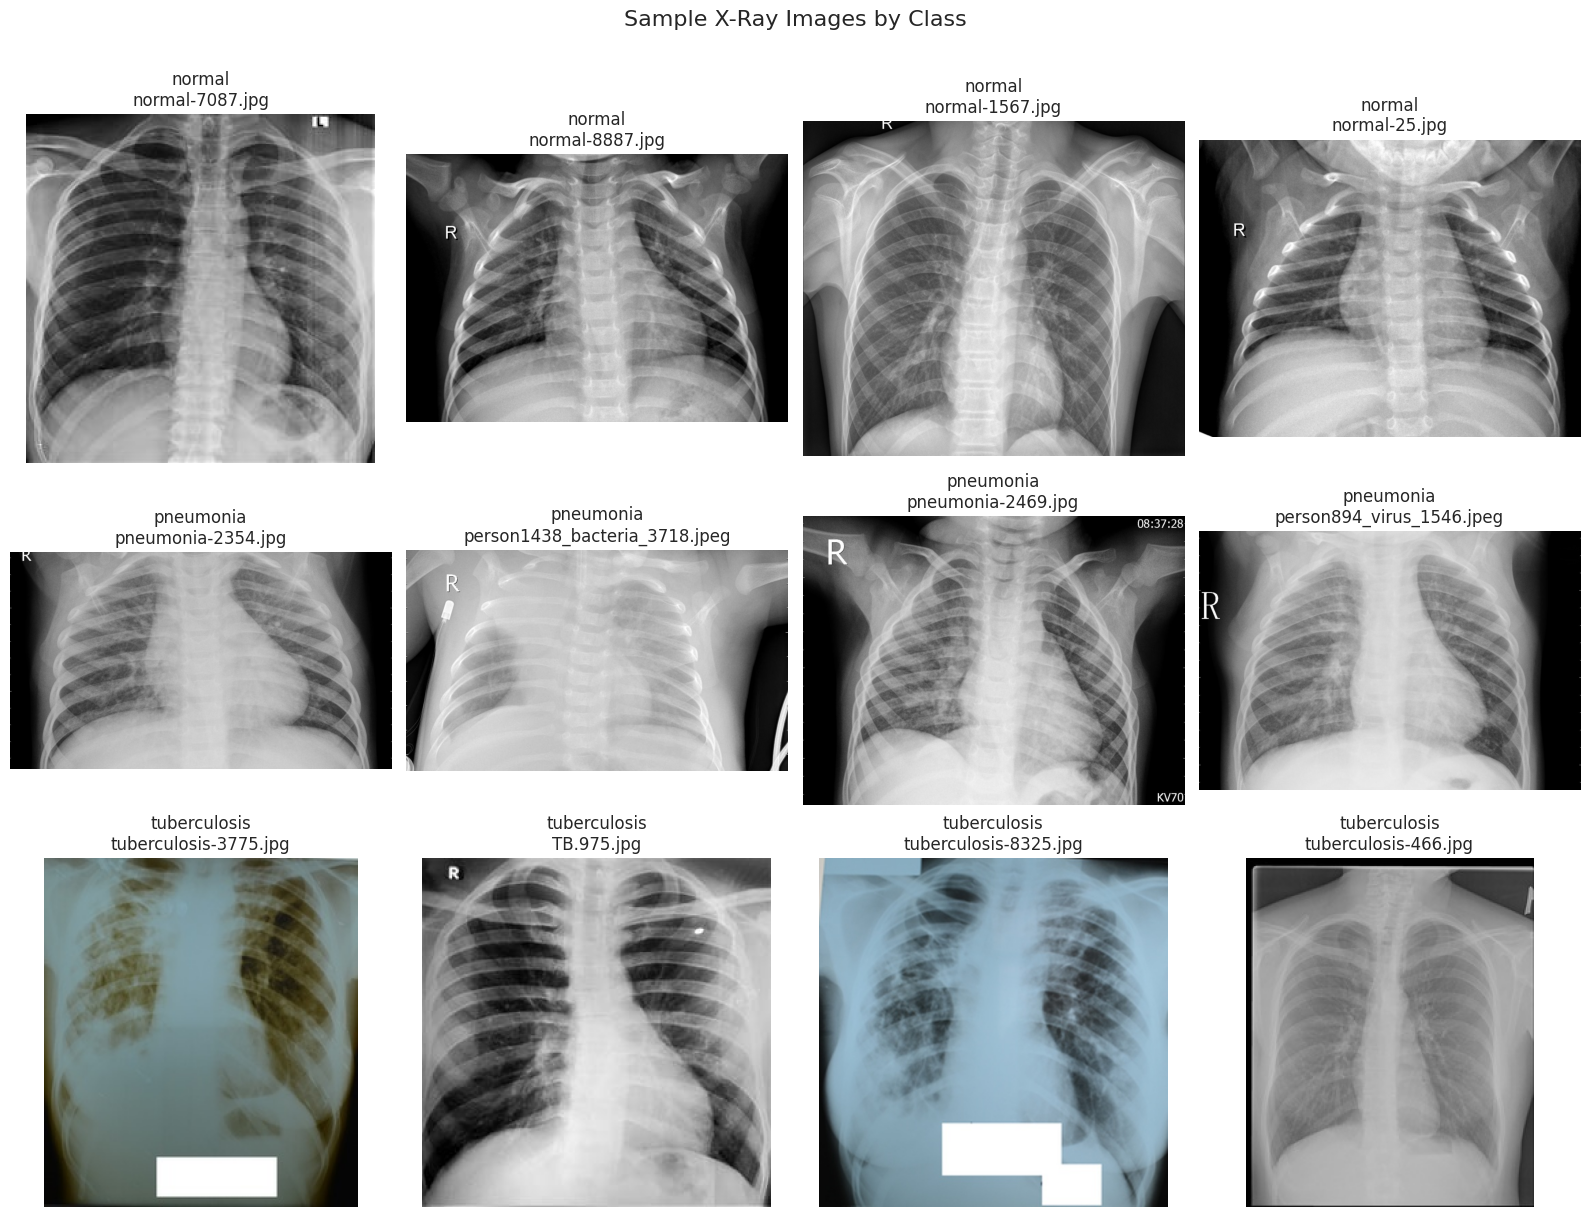

In [7]:
def visualize_samples(df: pd.DataFrame, n_samples: int = 4):
    """Visualize sample images from each class (n_samples per row)."""
    
    classes = sorted(df["class"].unique())
    n_classes = len(classes)
    
    fig, axes = plt.subplots(n_classes, n_samples, figsize=(n_samples * 4, n_classes * 4))
    
    for i, class_name in enumerate(classes):
        class_df = df[df["class"] == class_name]
        samples = class_df.sample(n=min(n_samples, len(class_df)))
        
        for j, (_, row) in enumerate(samples.iterrows()):
            img = Image.open(row["filepath"])
            if n_classes == 1:
                ax = axes[j]
            else:
                ax = axes[i, j]
            ax.imshow(img, cmap="gray")
            ax.set_title(f"{class_name}\n{row['filename'][:30]}")
            ax.axis("off")
    
    plt.suptitle("Sample X-Ray Images by Class", fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

# Show samples
if len(df) > 0:
    visualize_samples(df, n_samples=4)
else:
    print("No images found. Please download datasets first.")

## 7. Image Resolution & Size Distribution
Analyze width, height, and aspect ratio across the dataset to inform preprocessing resize choices.

In [8]:
def get_image_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Collect width, height, channels, and file size for each image."""
    stats = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Scanning images"):
        try:
            img = Image.open(row["filepath"])
            w, h = img.size
            mode = img.mode  # 'L' = grayscale, 'RGB', etc.
            channels = len(img.getbands())
            file_size_kb = os.path.getsize(row["filepath"]) / 1024
            stats.append({
                "width": w,
                "height": h,
                "aspect_ratio": round(w / h, 3),
                "mode": mode,
                "channels": channels,
                "file_size_kb": round(file_size_kb, 1),
            })
        except Exception as e:
            stats.append({
                "width": None, "height": None, "aspect_ratio": None,
                "mode": None, "channels": None, "file_size_kb": None,
            })
    return pd.concat([df.reset_index(drop=True), pd.DataFrame(stats)], axis=1)

df_stats = get_image_stats(df)

Scanning images:   0%|          | 0/34356 [00:00<?, ?it/s]

In [9]:
df_stats[["filename", "class", "split", "width", "height", "aspect_ratio", "mode", "channels", "file_size_kb"]]

,filename,class,split,width,height,aspect_ratio,mode,channels,file_size_kb
0,normal-3873.jpg,normal,train,1024,1024,1.000,RGB,3,180.9
1,IM-0525-0001-0001.jpeg,normal,train,1268,1017,1.247,L,1,342.3
2,normal-3378.jpg,normal,train,1932,1908,1.013,RGB,3,788.7
3,normal-3535.jpg,normal,train,512,512,1.000,RGB,3,54.6
4,NORMAL2-IM-1128-0001-0002.jpeg,normal,train,1414,1164,1.215,L,1,418.3
...,...,...,...,...,...,...,...,...,...
34351,tuberculosis-208.jpg,tuberculosis,test,256,226,1.133,RGB,3,14.7
34352,TB.303.jpg,tuberculosis,test,252,221,1.140,RGB,3,35.0
34353,tuberculosis-205.jpg,tuberculosis,test,512,512,1.000,RGB,3,57.9
34354,TB.881.jpg,tuberculosis,test,256,256,1.000,RGB,3,9.3


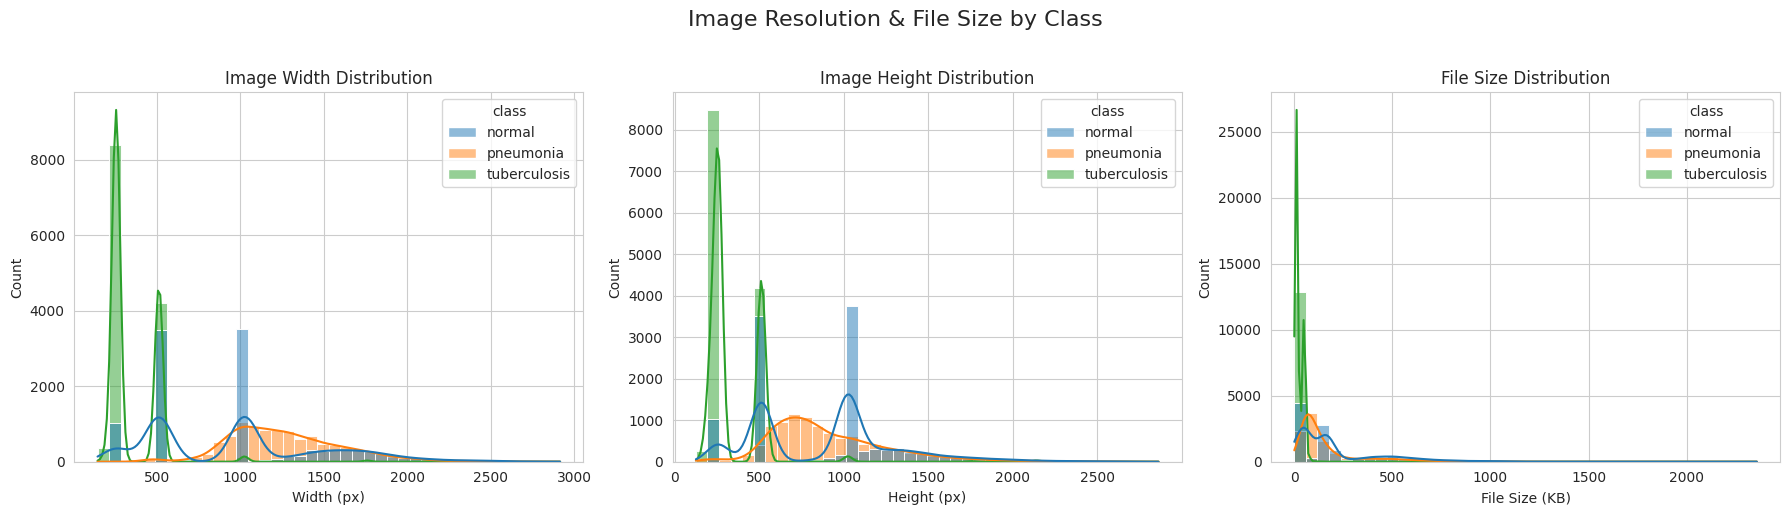


Top 10 most common resolutions (W x H):
  512 x 512: 7694 images
  256 x 256: 6938 images
  1024 x 1024: 3625 images
  256 x 211: 887 images
  211 x 256: 311 images
  256 x 192: 114 images
  256 x 246: 94 images
  256 x 191: 60 images
  256 x 204: 32 images
  256 x 215: 29 images


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Width distribution
sns.histplot(data=df_stats, x="width", hue="class", bins=40, kde=True, ax=axes[0])
axes[0].set_title("Image Width Distribution")
axes[0].set_xlabel("Width (px)")

# Height distribution
sns.histplot(data=df_stats, x="height", hue="class", bins=40, kde=True, ax=axes[1])
axes[1].set_title("Image Height Distribution")
axes[1].set_xlabel("Height (px)")

# File size distribution
sns.histplot(data=df_stats, x="file_size_kb", hue="class", bins=40, kde=True, ax=axes[2])
axes[2].set_title("File Size Distribution")
axes[2].set_xlabel("File Size (KB)")

plt.suptitle("Image Resolution & File Size by Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Most common resolutions
print("\nTop 10 most common resolutions (W x H):")
res_counts = df_stats.groupby(["width", "height"]).size().sort_values(ascending=False).head(10)
for (w, h), count in res_counts.items():
    print(f"  {w} x {h}: {count} images")

## 8. Pixel Intensity Histograms per Class
Compare mean pixel intensity distributions — can reveal scanning protocol or contrast differences between classes.

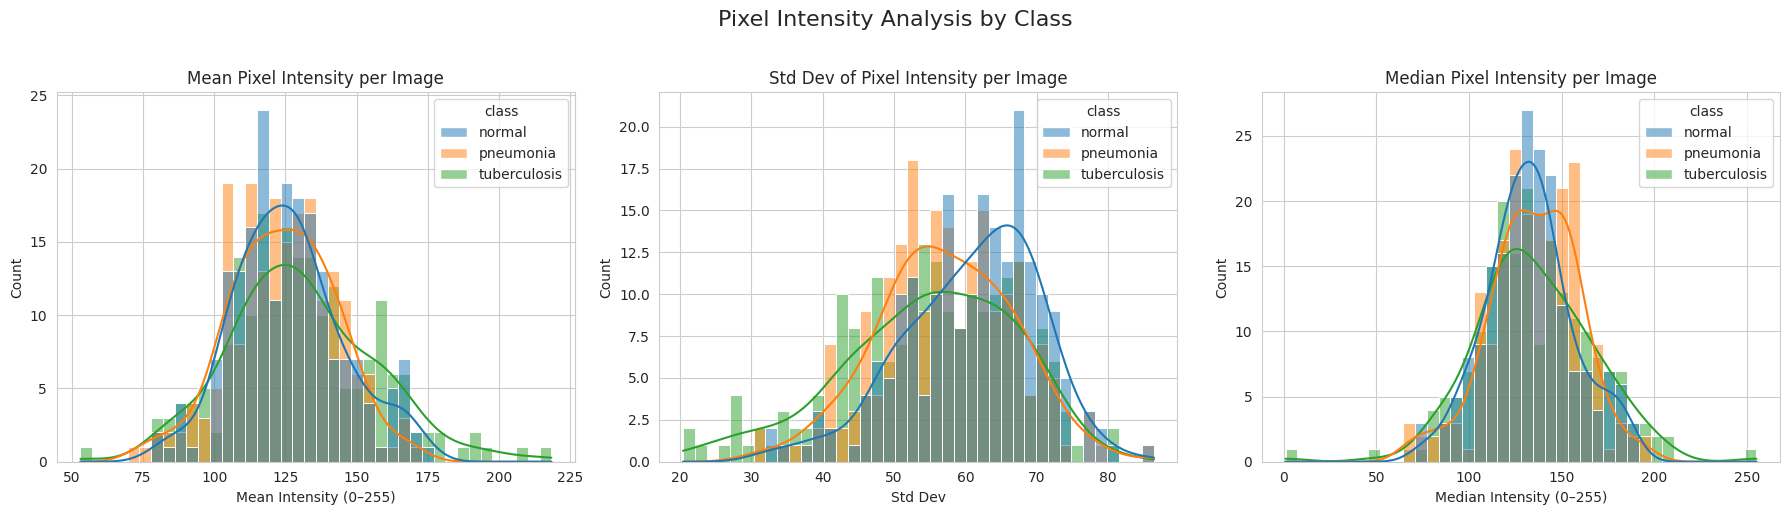


Intensity Statistics by Class:
             mean_intensity            std_intensity      
                       mean        std          mean   std
class                                                     
normal           126.000000  19.000000     60.900002   9.4
pneumonia        124.000000  18.700001     57.200001   9.5
tuberculosis     130.399994  25.799999     54.900002  12.1


In [11]:
def compute_mean_pixel_intensity(df: pd.DataFrame, sample_n: int = 200) -> pd.DataFrame:
    """Compute mean pixel intensity for a sample of images per class."""
    records = []
    for cls in df["class"].unique():
        class_df = df[df["class"] == cls]
        sample = class_df.sample(n=min(sample_n, len(class_df)), random_state=42)
        for _, row in sample.iterrows():
            try:
                img = Image.open(row["filepath"]).convert("L")  # grayscale
                arr = np.array(img, dtype=np.float32)
                records.append({
                    "class": cls,
                    "mean_intensity": arr.mean(),
                    "std_intensity": arr.std(),
                    "median_intensity": np.median(arr),
                })
            except Exception:
                continue
    return pd.DataFrame(records)

intensity_df = compute_mean_pixel_intensity(df, sample_n=200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mean intensity
sns.histplot(data=intensity_df, x="mean_intensity", hue="class", bins=40, kde=True, ax=axes[0])
axes[0].set_title("Mean Pixel Intensity per Image")
axes[0].set_xlabel("Mean Intensity (0–255)")

# Std intensity
sns.histplot(data=intensity_df, x="std_intensity", hue="class", bins=40, kde=True, ax=axes[1])
axes[1].set_title("Std Dev of Pixel Intensity per Image")
axes[1].set_xlabel("Std Dev")

# Median intensity
sns.histplot(data=intensity_df, x="median_intensity", hue="class", bins=40, kde=True, ax=axes[2])
axes[2].set_title("Median Pixel Intensity per Image")
axes[2].set_xlabel("Median Intensity (0–255)")

plt.suptitle("Pixel Intensity Analysis by Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print("\nIntensity Statistics by Class:")
print(intensity_df.groupby("class")[["mean_intensity", "std_intensity"]].agg(["mean", "std"]).round(1))

## 9. Processed Data — Per-Split Class Distribution
Load the processed manifest generated by `run_processing_pipeline` and verify class balance is preserved after preprocessing.

Processed images: 22813

Per split/class breakdown:
class  normal  pneumonia  tuberculosis
split                                 
test      639        483          1027
train    4526       7249          7037
val       420        404          1028


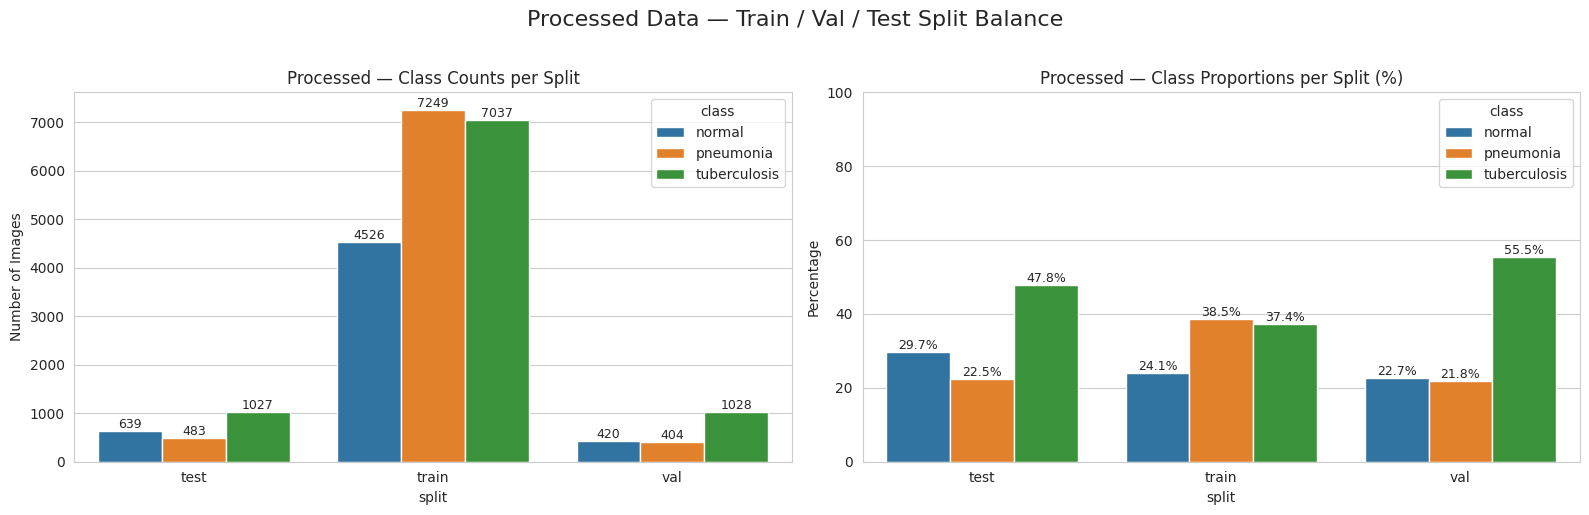


--- Raw vs Processed Comparison ---
Images removed during processing (raw - processed):
class  normal  pneumonia  tuberculosis
split                                 
test      592        167           402
train    4434       1592          3213
val       565        174           404


In [12]:
# Load the processed manifest
PROJECT_ROOT = Path().absolute().parent  # notebooks/ -> project root
QUARANTINE_DIR = DATA_DIR / "quarantine"
processed_manifest_path = PROCESSED_DIR / "manifest.csv"

if processed_manifest_path.exists():
    df_processed = pd.read_csv(processed_manifest_path)
    
    # Manifest paths are relative to the project root — resolve them
    df_processed["filepath_processed"] = df_processed["filepath_processed"].apply(
        lambda p: str(PROJECT_ROOT / p)
    )
    df_processed["filepath_original"] = df_processed["filepath_original"].apply(
        lambda p: str(PROJECT_ROOT / p)
    )
    
    print(f"Processed images: {len(df_processed)}")
    print(f"\nPer split/class breakdown:")
    proc_split_class = df_processed.groupby(["split", "class"]).size().unstack(fill_value=0)
    print(proc_split_class)

    # Grouped bar chart
    proc_melted = proc_split_class.reset_index().melt(
        id_vars="split", var_name="class", value_name="count"
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Absolute counts
    sns.barplot(data=proc_melted, x="split", y="count", hue="class", ax=axes[0])
    axes[0].set_title("Processed — Class Counts per Split")
    axes[0].set_ylabel("Number of Images")
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt="%d", fontsize=9)

    # Proportions
    proc_pct = proc_split_class.div(proc_split_class.sum(axis=1), axis=0) * 100
    proc_pct_melted = proc_pct.reset_index().melt(
        id_vars="split", var_name="class", value_name="percentage"
    )
    sns.barplot(data=proc_pct_melted, x="split", y="percentage", hue="class", ax=axes[1])
    axes[1].set_title("Processed — Class Proportions per Split (%)")
    axes[1].set_ylabel("Percentage")
    axes[1].set_ylim(0, 100)
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt="%.1f%%", fontsize=9)

    plt.suptitle("Processed Data — Train / Val / Test Split Balance", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    # Compare raw vs processed counts
    print("\n--- Raw vs Processed Comparison ---")
    raw_counts = df.groupby(["split", "class"]).size().unstack(fill_value=0)
    diff = raw_counts - proc_split_class.reindex_like(raw_counts).fillna(0).astype(int)
    print("Images removed during processing (raw - processed):")
    print(diff)
else:
    print(f"⚠️  Processed manifest not found at {processed_manifest_path}")
    print("   Run the processing pipeline first: python -m xclinvision.processing")
    df_processed = pd.DataFrame()

## 10. Quarantined Data — Corrupted & Flagged Samples
Visualize images quarantined by the processing pipeline (`process_and_filter_xray`).
- **Corrupted**: images that failed to load or are blank / near-uniform
- **Flagged**: images filtered due to too-small X-ray content area (ratio < `DEFAULT_MIN_AREA_RATIO = 0.15`)

Total quarantined images: 155

Breakdown by category:
category
Flagged      154
Corrupted      1
Name: count, dtype: int64

Per split/class/category:
class            normal  pneumonia  tuberculosis
category  split                                 
Corrupted train       0          0             1
Flagged   test        0         13             2
          train       2        103            22
          val         0         10             2


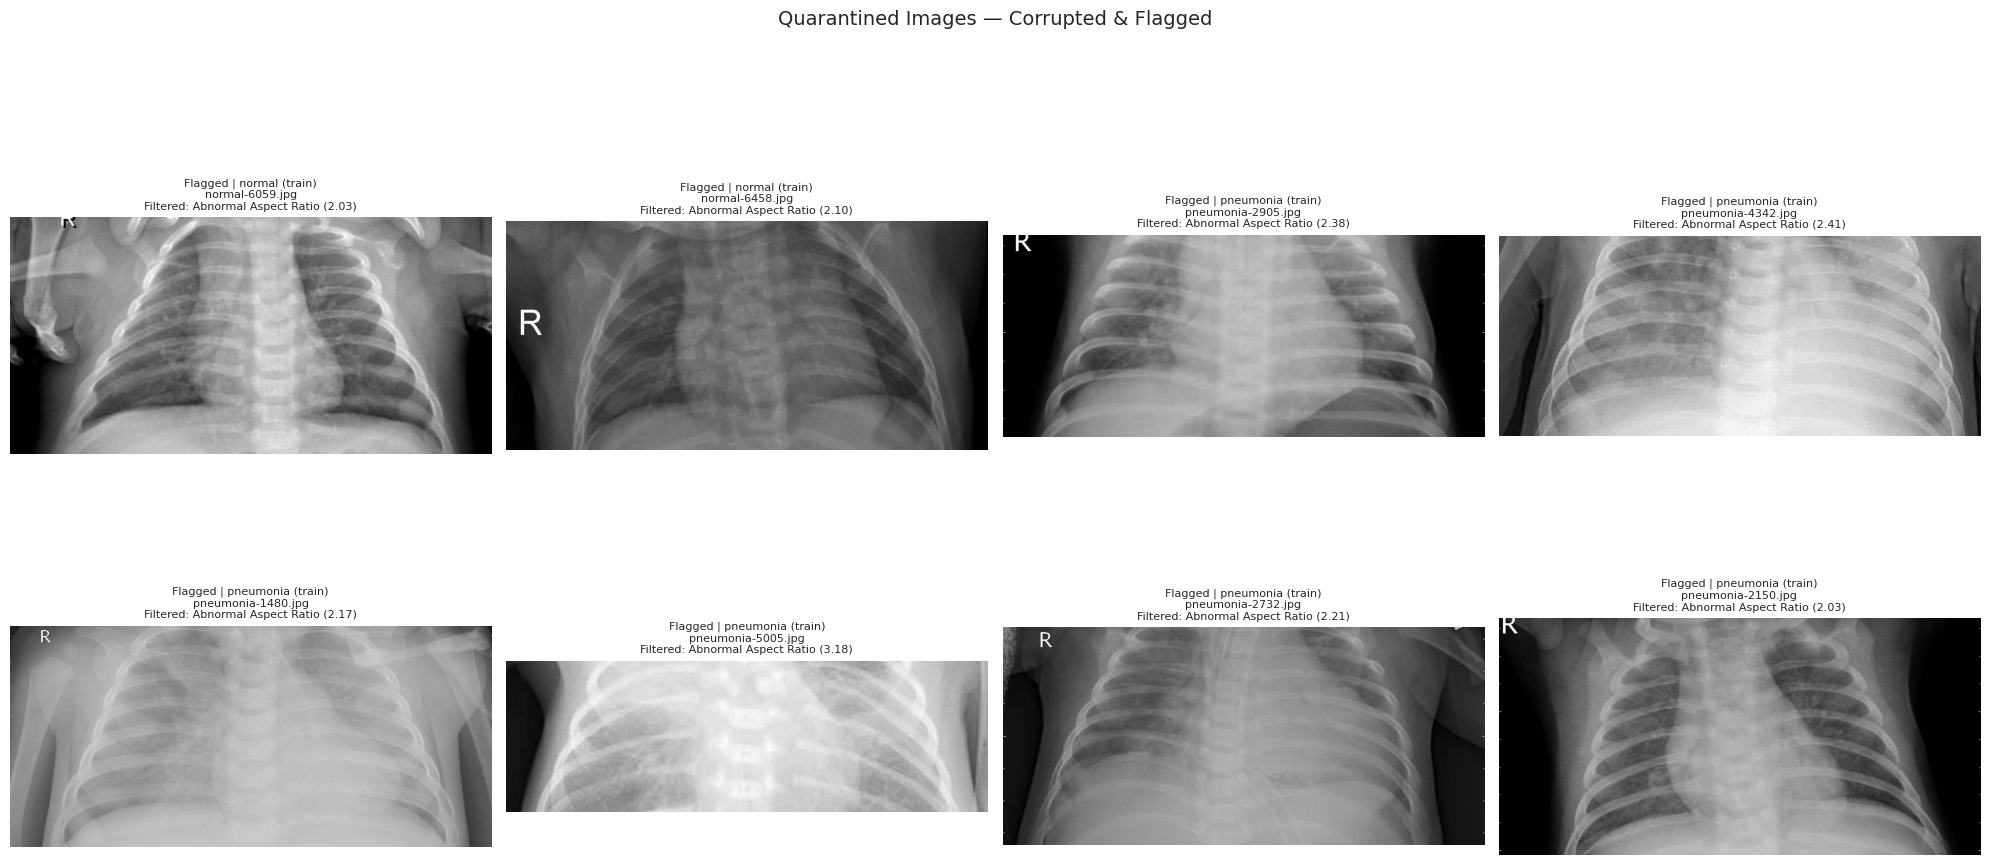


Quarantine Reasons:
  Filtered: Abnormal Aspect Ratio (2.07): 7
  Filtered: Abnormal Aspect Ratio (2.15): 6
  Filtered: Abnormal Aspect Ratio (2.02): 6
  Filtered: Abnormal Aspect Ratio (2.03): 5
  Filtered: Abnormal Aspect Ratio (2.10): 5
  Filtered: Abnormal Aspect Ratio (2.41): 4
  Filtered: Abnormal Aspect Ratio (2.17): 4
  Filtered: Abnormal Aspect Ratio (2.06): 4
  Filtered: Abnormal Aspect Ratio (2.08): 4
  Filtered: Abnormal Aspect Ratio (2.04): 4
  Filtered: X-ray area too small (0.24): 4
  Filtered: Abnormal Aspect Ratio (2.05): 3
  Filtered: Abnormal Aspect Ratio (2.09): 3
  Filtered: Abnormal Aspect Ratio (2.22): 3
  Filtered: Abnormal Aspect Ratio (2.12): 3
  Filtered: Abnormal Aspect Ratio (2.20): 3
  Filtered: Abnormal Aspect Ratio (2.16): 3
  Filtered: Abnormal Aspect Ratio (2.25): 3
  Filtered: Abnormal Aspect Ratio (2.13): 3
  Filtered: Abnormal Aspect Ratio (2.49): 3
  Filtered: X-ray area too small (0.17): 3
  Filtered: X-ray area too small (0.20): 3
  Filtered: X-

In [38]:
quarantine_manifest_path = QUARANTINE_DIR / "quarantine_manifest.csv"

if quarantine_manifest_path.exists():
    df_quarantine = pd.read_csv(quarantine_manifest_path)
    
    # Resolve relative paths from project root
    for col in ["filepath_original", "filepath_quarantine"]:
        df_quarantine[col] = df_quarantine[col].apply(lambda p: str(PROJECT_ROOT / p))
    
    print(f"Total quarantined images: {len(df_quarantine)}")
    
    df_quarantine["category"] = df_quarantine["reason"].apply(
        lambda r: "Corrupted" if r.startswith("Error") else "Flagged"
    )
    print(f"\nBreakdown by category:")
    print(df_quarantine["category"].value_counts())
    print(f"\nPer split/class/category:")
    print(df_quarantine.groupby(["category", "split", "class"]).size().unstack(fill_value=0))

    # --- Visualize quarantined samples ---
    n_show = min(8, len(df_quarantine))
    if n_show > 0:
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        axes = axes.flatten()

        for idx, (_, row) in enumerate(df_quarantine.head(n_show).iterrows()):
            ax = axes[idx]
            try:
                img = Image.open(row["filepath_quarantine"]).convert("L")
                ax.imshow(np.array(img), cmap="gray")
            except Exception:
                ax.text(0.5, 0.5, "Cannot\nLoad", ha="center", va="center",
                        fontsize=14, color="red", transform=ax.transAxes)

            ax.set_title(
                f"{row['category']} | {row['class']} ({row['split']})\n"
                f"{Path(row['filepath_original']).name[:35]}\n"
                f"{row['reason'][:50]}",
                fontsize=8,
            )
            ax.axis("off")

        for idx in range(n_show, len(axes)):
            axes[idx].axis("off")

        plt.suptitle("Quarantined Images — Corrupted & Flagged", fontsize=14, y=1.01)
        plt.tight_layout()
        plt.show()

    # Reason summary
    print("\nQuarantine Reasons:")
    for reason, count in df_quarantine["reason"].value_counts().items():
        print(f"  {reason}: {count}")
else:
    print(f"⚠️  Quarantine manifest not found at {quarantine_manifest_path}")
    print("   Run the processing pipeline first.")
    df_quarantine = pd.DataFrame()

## 11. Processed Data — Image Resolution & Size Distribution
Verify that all processed images have the expected target dimensions after preprocessing (auto-crop + CLAHE + letterbox resize).

Scanning processed images:   0%|          | 0/22813 [00:00<?, ?it/s]

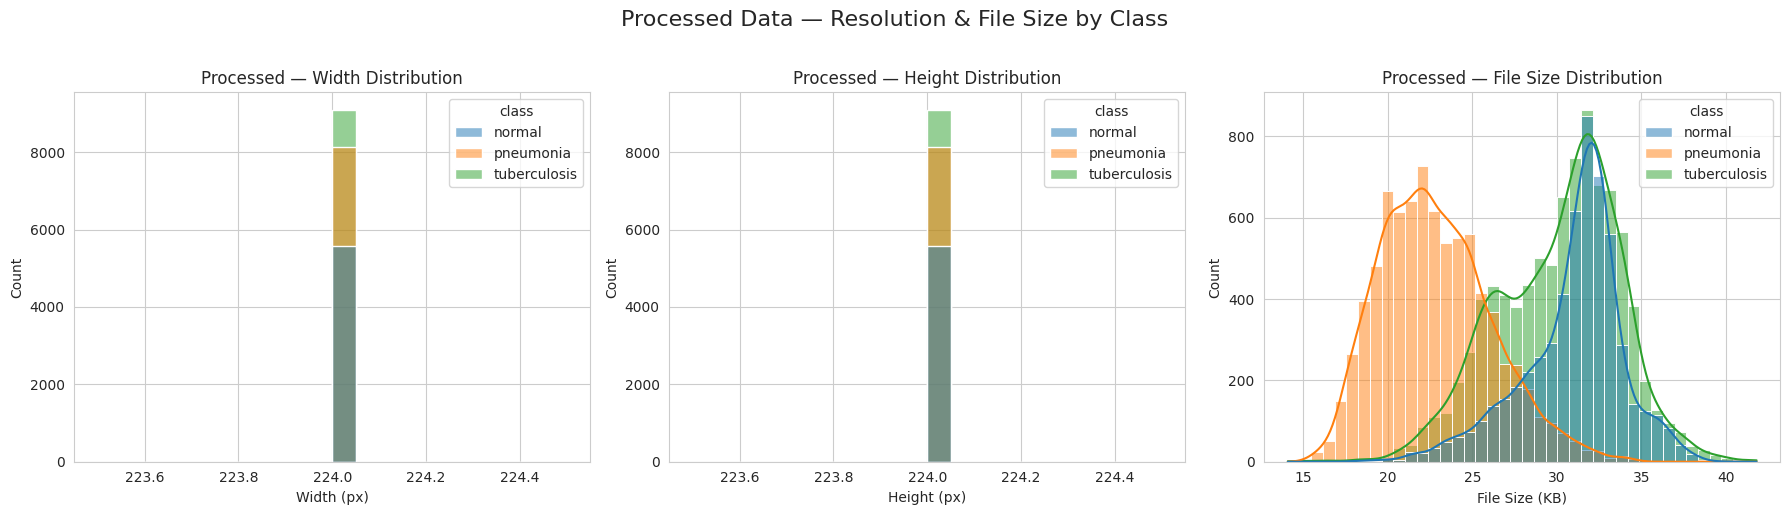


Unique resolutions in processed data:
  224 x 224: 22813 images


In [13]:
if not df_processed.empty:
    proc_stats = []
    for _, row in tqdm(df_processed.iterrows(), total=len(df_processed), desc="Scanning processed images"):
        try:
            img = Image.open(row["filepath_processed"])
            w, h = img.size
            file_size_kb = os.path.getsize(row["filepath_processed"]) / 1024
            proc_stats.append({
                "width": w, "height": h,
                "aspect_ratio": round(w / h, 3),
                "file_size_kb": round(file_size_kb, 1),
            })
        except Exception:
            proc_stats.append({"width": None, "height": None, "aspect_ratio": None, "file_size_kb": None})

    df_proc_stats = pd.concat([df_processed.reset_index(drop=True), pd.DataFrame(proc_stats)], axis=1)

    # Only use kde=True when there are multiple unique values (all processed
    # images may share identical target dimensions, causing kde to fail).
    use_kde_w = df_proc_stats["width"].nunique() > 1
    use_kde_h = df_proc_stats["height"].nunique() > 1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(data=df_proc_stats, x="width", hue="class", bins=20, kde=use_kde_w, ax=axes[0])
    axes[0].set_title("Processed — Width Distribution")
    axes[0].set_xlabel("Width (px)")

    sns.histplot(data=df_proc_stats, x="height", hue="class", bins=20, kde=use_kde_h, ax=axes[1])
    axes[1].set_title("Processed — Height Distribution")
    axes[1].set_xlabel("Height (px)")

    sns.histplot(data=df_proc_stats, x="file_size_kb", hue="class", bins=40, kde=True, ax=axes[2])
    axes[2].set_title("Processed — File Size Distribution")
    axes[2].set_xlabel("File Size (KB)")

    plt.suptitle("Processed Data — Resolution & File Size by Class", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    # Unique resolutions
    print("\nUnique resolutions in processed data:")
    res_counts = df_proc_stats.groupby(["width", "height"]).size().sort_values(ascending=False)
    for (w, h), count in res_counts.items():
        print(f"  {w} x {h}: {count} images")
else:
    print("⚠️  No processed data available — skipping.")

## 12. Processed Data — Pixel Intensity per Class
Compare intensity distributions **after** CLAHE and preprocessing. These should look more uniform
than the raw data since contrast enhancement normalizes brightness differences.

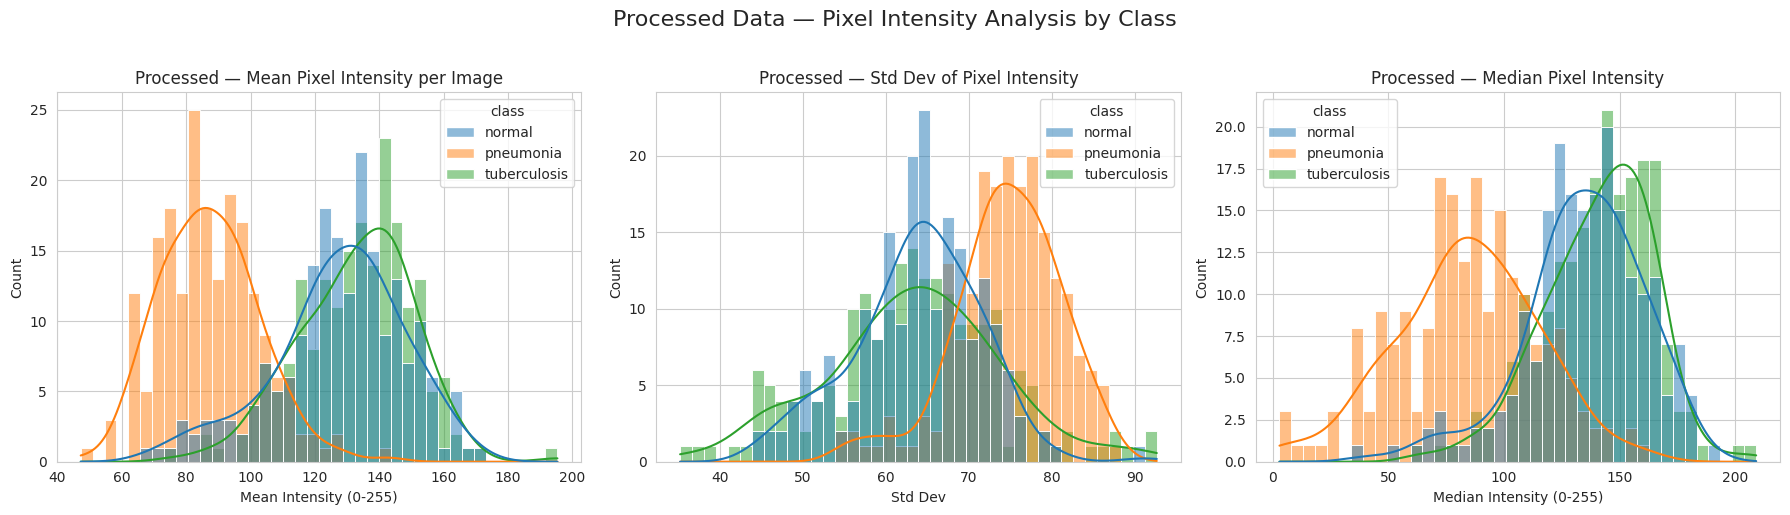


Processed Intensity Statistics by Class:
             mean_intensity            std_intensity      
                       mean        std          mean   std
class                                                     
normal           127.500000  20.299999     63.700001   7.7
pneumonia         87.099998  15.200000     74.699997   6.4
tuberculosis     132.800003  17.799999     63.299999  10.5


In [14]:
if not df_processed.empty:
    proc_intensity = []
    for cls in df_processed["class"].unique():
        class_df = df_processed[df_processed["class"] == cls]
        sample = class_df.sample(n=min(200, len(class_df)), random_state=42)
        for _, row in sample.iterrows():
            try:
                img = Image.open(row["filepath_processed"]).convert("L")
                arr = np.array(img, dtype=np.float32)
                proc_intensity.append({
                    "class": cls,
                    "mean_intensity": arr.mean(),
                    "std_intensity": arr.std(),
                    "median_intensity": np.median(arr),
                })
            except Exception:
                continue

    if proc_intensity:
        proc_intensity_df = pd.DataFrame(proc_intensity)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        sns.histplot(data=proc_intensity_df, x="mean_intensity", hue="class", bins=40, kde=True, ax=axes[0])
        axes[0].set_title("Processed — Mean Pixel Intensity per Image")
        axes[0].set_xlabel("Mean Intensity (0-255)")

        sns.histplot(data=proc_intensity_df, x="std_intensity", hue="class", bins=40, kde=True, ax=axes[1])
        axes[1].set_title("Processed — Std Dev of Pixel Intensity")
        axes[1].set_xlabel("Std Dev")

        sns.histplot(data=proc_intensity_df, x="median_intensity", hue="class", bins=40, kde=True, ax=axes[2])
        axes[2].set_title("Processed — Median Pixel Intensity")
        axes[2].set_xlabel("Median Intensity (0-255)")

        plt.suptitle("Processed Data — Pixel Intensity Analysis by Class", fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()

        print("\nProcessed Intensity Statistics by Class:")
        print(proc_intensity_df.groupby("class")[["mean_intensity", "std_intensity"]].agg(["mean", "std"]).round(1))
    else:
        print("⚠️  Could not read any processed images — check file paths.")
else:
    print("⚠️  No processed data available — skipping.")

## 13. Channel & Color Mode Analysis
Confirm whether all images are grayscale (`L`) or RGB. Mixed modes require normalisation during preprocessing.

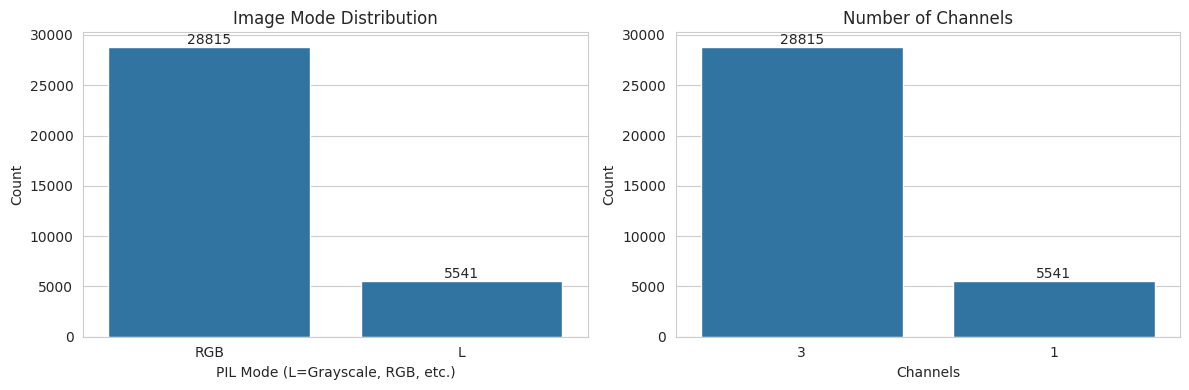


Mode per class:
mode             L    RGB
class                    
normal        1579   9597
pneumonia     3962   6107
tuberculosis     0  13111

💡 Recommendation: Convert all images to a consistent mode (e.g. RGB or L) during preprocessing.


In [15]:
# Channel / mode breakdown (uses df_stats from section 6)
mode_counts = df_stats["mode"].value_counts()
channel_counts = df_stats["channels"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Mode distribution
sns.barplot(x=mode_counts.index.astype(str), y=mode_counts.values, ax=axes[0])
axes[0].set_title("Image Mode Distribution")
axes[0].set_xlabel("PIL Mode (L=Grayscale, RGB, etc.)")
axes[0].set_ylabel("Count")
for i, v in enumerate(mode_counts.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

# Channel count distribution
sns.barplot(x=channel_counts.index.astype(str), y=channel_counts.values, ax=axes[1])
axes[1].set_title("Number of Channels")
axes[1].set_xlabel("Channels")
axes[1].set_ylabel("Count")
for i, v in enumerate(channel_counts.values):
    axes[1].text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

# Per-class mode breakdown
print("\nMode per class:")
print(df_stats.groupby(["class", "mode"]).size().unstack(fill_value=0))
print("\n💡 Recommendation: Convert all images to a consistent mode (e.g. RGB or L) during preprocessing.")

## 13b. File Format Distribution
Check which image formats are present in the raw dataset.

File Format Distribution:
  .jpg: 28532 (83.0%)
  .jpeg: 5824 (17.0%)

Format per class:
extension     .jpeg   .jpg
class                     
normal         1579   9597
pneumonia      4245   5824
tuberculosis      0  13111


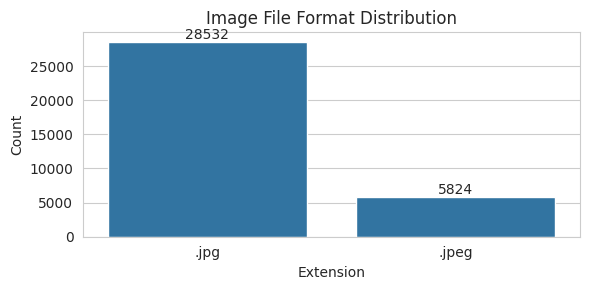


💡 All images are .jpg — use the same format during preprocessing to avoid unnecessary re-encoding.


In [18]:
# File extension distribution
df["extension"] = df["filename"].apply(lambda f: Path(f).suffix.lower())
ext_counts = df["extension"].value_counts()

print("File Format Distribution:")
for ext, count in ext_counts.items():
    pct = count / len(df) * 100
    print(f"  {ext}: {count} ({pct:.1f}%)")

# Per-class breakdown
print("\nFormat per class:")
print(df.groupby(["class", "extension"]).size().unstack(fill_value=0))

# Bar chart
fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(x=ext_counts.index.astype(str), y=ext_counts.values, ax=ax)
ax.set_title("Image File Format Distribution")
ax.set_xlabel("Extension")
ax.set_ylabel("Count")
for i, v in enumerate(ext_counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(f"\n💡 All images are {ext_counts.index[0]} — use the same format during preprocessing to avoid unnecessary re-encoding.")

## 14. Summary Statistics

In [20]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total raw images:       {len(df)}")
print(f"Number of classes:      {df['class'].nunique() if len(df) > 0 else 0}")
print(f"Classes:                {sorted(df['class'].unique().tolist()) if len(df) > 0 else 'N/A'}")

print("\nRaw class balance:")
if len(df) > 0:
    for cls, count in df["class"].value_counts().items():
        pct = count / len(df) * 100
        print(f"  {cls}: {count} ({pct:.1f}%)")

if "width" in df_stats.columns:
    print(f"\nRaw resolution range:   "
          f"{int(df_stats['width'].min())}x{int(df_stats['height'].min())} -> "
          f"{int(df_stats['width'].max())}x{int(df_stats['height'].max())}")
    print(f"Image modes:            {df_stats['mode'].unique().tolist()}")

print(f"\n--- After Processing Pipeline ---")
if not df_processed.empty:
    print(f"Processed images:       {len(df_processed)}")
else:
    print(f"Processed images:       N/A (run pipeline first)")

try:
    if not df_quarantine.empty:
        n_corrupted = (df_quarantine["category"] == "Corrupted").sum()
        n_flagged = (df_quarantine["category"] == "Flagged").sum()
        print(f"Quarantined (corrupted): {n_corrupted}")
        print(f"Quarantined (flagged):   {n_flagged}")
    else:
        print(f"Quarantined images:     0")
except NameError:
    print(f"Quarantined images:     N/A (run pipeline first)")

print("=" * 60)

DATASET SUMMARY
Total raw images:       34356
Number of classes:      3
Classes:                ['normal', 'pneumonia', 'tuberculosis']

Raw class balance:
  tuberculosis: 13111 (38.2%)
  normal: 11176 (32.5%)
  pneumonia: 10069 (29.3%)

Raw resolution range:   144x124 -> 2916x2863
Image modes:            ['RGB', 'L']

--- After Processing Pipeline ---
Processed images:       22813
Quarantined images:     N/A (run pipeline first)
